#  Hypothesis Testing Activity<hr style="border:2.5px solid #126782"></hr>

<b>Rex Orly Mallorca</b>
<br>CompTech Student

In [3]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [4]:
# load datasets
df = pd.read_csv(r"datasets\calorie_dataset_100_samples.csv",
                 delimiter=",")
df

,protein_g,carbs_g,fat_g,fiber_g,sugar_g,calories,calorie_class
0,22.5,65.2,13.7,9.9,26.7,479,medium
1,15.9,20.7,16.8,7.6,15.0,316,low
2,28.3,62.4,14.5,10.8,15.3,524,medium
3,23.3,18.6,7.9,17.0,0.2,250,low
4,30.8,55.1,31.9,12.5,7.2,602,medium
...,...,...,...,...,...,...,...
95,13.5,14.6,12.8,3.3,25.8,222,low
96,19.2,60.7,34.6,4.5,15.5,623,medium
97,16.8,78.3,21.7,7.1,11.3,600,medium
98,28.2,52.6,14.1,12.0,11.4,450,medium


In [5]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   protein_g      100 non-null    float64
 1   carbs_g        100 non-null    float64
 2   fat_g          100 non-null    float64
 3   fiber_g        100 non-null    float64
 4   sugar_g        100 non-null    float64
 5   calories       100 non-null    int64  
 6   calorie_class  100 non-null    object 
dtypes: float64(5), int64(1), object(1)
memory usage: 5.6+ KB


In [6]:
# summary of statistics
df.describe()

,protein_g,carbs_g,fat_g,fiber_g,sugar_g,calories
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,24.758000,51.066000,20.172000,7.50100,15.317000,483.710000
std,9.832251,22.121511,8.004684,3.96631,8.879906,120.594428
min,1.100000,4.900000,0.000000,0.00000,0.000000,179.000000
25%,18.650000,32.650000,15.150000,4.57500,10.150000,399.500000
50%,24.650000,50.650000,19.650000,7.15000,15.400000,493.000000
75%,30.925000,64.825000,25.200000,10.12500,20.850000,574.750000
max,52.200000,106.500000,41.000000,17.00000,40.000000,720.000000


# 2-Sample t-Test

## Protein and Sugar

In [7]:
"""
Summary of Statistics
"""
df[['protein_g','sugar_g']].describe()

,protein_g,sugar_g
count,100.000000,100.000000
mean,24.758000,15.317000
std,9.832251,8.879906
min,1.100000,0.000000
25%,18.650000,10.150000
50%,24.650000,15.400000
75%,30.925000,20.850000
max,52.200000,40.000000


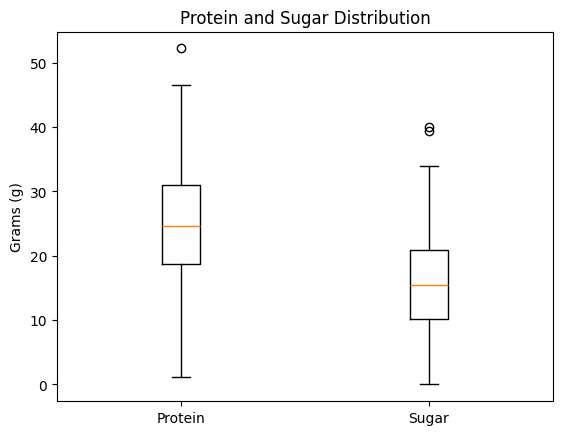

In [8]:
"""
Boxplot
----------------
"""
# check for outliers
plt.boxplot(df[['protein_g','sugar_g']], tick_labels=['Protein','Sugar'])
plt.title("Protein and Sugar Distribution")
plt.ylabel('Grams (g)')
plt.show()

In [9]:
"""
Normality Test
------------------
"""
# shapiro-wilk normality test
print("\nProtein:")
w_stat, p_value = stats.shapiro(df['protein_g'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nSugar:")
w_stat, p_value = stats.shapiro(df['sugar_g'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")


Protein:
w_stat: 0.9934
P-value: 0.9135
Normal data

Sugar:
w_stat: 0.9755
P-value: 0.0588
Normal data


In [10]:
"""
F-Test 
--------------------------------
Ho: var_protein = var_sugar
Ha: var_protein != var_sugar
"""

var_protein = df['protein_g'].var(ddof=1)
var_sugar = df['sugar_g'].var(ddof=1)

# F-statistic
if var_protein > var_sugar:
    f_stat = var_protein/var_sugar
else:
    f_stat = var_sugar/var_protein

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_protein = df['protein_g'].count()-1
dof_sugar = df['sugar_g'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_protein, dof_sugar)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 1.2260
p_value = 0.1562
equal variances


In [11]:
"""
2 - Sample T-Test
----------------------------------------
Ho: Protein <= Sugar
Ha: Protein > Sugar
"""

t_stat, p_value = stats.ttest_ind(df['protein_g'],df['sugar_g'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Protein nutritional value is significantly higher than sugar nutritional value.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between Protein nutritional value and sugar nutritional value.")

t_stat = 7.1260
p_value = 0.0000
Protein nutritional value is significantly higher than sugar nutritional value.


In [12]:
"""
Power of the Test
------------------
Ho: μprotein ≤ μsugar
Ha: μprotein > μsugar
"""
    
# cohen's d
protein_mean = df['protein_g'].mean()
sugar_mean = df['sugar_g'].mean()
protein_std = df['protein_g'].std(ddof=1)

d = abs((protein_mean - sugar_mean)/protein_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['protein_g'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.9602
Power of the test: 100.00%
